# Titanic 11: ClassIsChild
이번 가설: 어린이의 생존 패턴이 등급마다 다를 수 있어 등급과 어린이 여부를 조합한다.
이전까지 채택된 추가 피처: ['GenderClass', 'GenderIsChild'].
이번 변경: **ClassIsChild 하나 추가**, 다른 모델·하이퍼파라미터 변경 없음. HasCabin/AgeMissing 제외 유지.

채택 규칙(평가 전 고정): 이전 Best보다 holdout AUC 상승 → 동일 5-fold 비교 → CV 평균 상승 및 Gap 증가 0.01 이내, CV 표준편차 증가 0.005 이내이면 채택. Gap 0.01과 CV 표준편차 0.005는 운영 기준이며 통계적 유의성 기준이 아니다.
CV도 이 데이터로 후보를 고르는 보조 검증이므로 반복 선택의 낙관성이 남는다. 여러 CV fold 결과로 새 threshold를 탐색하지 않는다.
CSV는 해당 버전에서 **실제로 실험한 후보 피처 집합**의 예측을 보존한다. 탈락 피처는 다음 버전의 입력에 누적하지 않는다. 최종 채택 Best와 실험 CSV를 구분한다.

# 1. 데이터 불러오기

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from common.utils import train_test_split_by_target
from common.interaction_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters

train = pd.read_csv('csv/train.csv')
test = pd.read_csv('csv/test.csv')
submission = pd.read_csv('csv/submission.csv')
previous_features = ['GenderClass', 'GenderIsChild']
new_feature = 'ClassIsChild'
candidate_features = previous_features + [new_feature]
previous_cv = {'mean': 0.9059066143619919, 'std': 0.017323969521877203}
print(train.shape, test.shape)
display(train.head())
display(test.head())

(916, 12) (393, 11)


,passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S
1,1,0,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q
2,2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.0,1,1,12749,93.5000,B69,S
3,3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
4,4,0,2,"Hold, Mr. Stephen",male,44.0,1,0,26707,26.0000,NaN,S


,passengerid,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,916,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
1,917,2,"Pinsky, Mrs. (Rosa)",female,32.0,0,0,234604,13.0000,NaN,S
2,918,3,"McCarthy, Miss. Catherine Katie""""",female,NaN,0,0,383123,7.7500,NaN,Q
3,919,3,"Franklin, Mr. Charles (Charles Fardon)",male,NaN,0,0,SOTON/O.Q. 3101314,7.2500,NaN,S
4,920,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S


# 2. 데이터 메타 정보 확인

In [3]:
train.info()
print(train.isna().sum())
print(train.nunique())
test.info()
print(test.isna().sum())
print('train에만:', set(train.columns)-set(test.columns))

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  916 non-null    int64  
 1   survived     916 non-null    int64  
 2   pclass       916 non-null    int64  
 3   name         916 non-null    str    
 4   gender       916 non-null    str    
 5   age          736 non-null    float64
 6   sibsp        916 non-null    int64  
 7   parch        916 non-null    int64  
 8   ticket       916 non-null    str    
 9   fare         916 non-null    float64
 10  cabin        198 non-null    str    
 11  embarked     915 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 86.0 KB
passengerid      0
survived         0
pclass           0
name             0
gender           0
age            180
sibsp            0
parch            0
ticket           0
fare             0
cabin          718
embarked         1
dtype: int64
passengerid    916

# 3. Target 정의

In [4]:
assert set(train.columns)-set(test.columns) == {'survived'}
assert set(test.columns)-set(train.columns) == set()
target_col = 'survived'
id_col = 'passengerid'
X = train.drop(columns=[target_col, id_col])
y = train[target_col]
X_test_raw = test.drop(columns=id_col)
assert X.columns.equals(X_test_raw.columns)
assert train[id_col].is_unique and test[id_col].is_unique
assert set(train[id_col]).isdisjoint(test[id_col])

# 4. Target 분석
Baseline과 같은 seed 42, stratify, validation 25%를 유지합니다.

In [5]:
print(y.value_counts(normalize=True))
train_part, valid_part = train_test_split_by_target(train, target_name=target_col)
X_tr_raw = train_part.drop(columns=[target_col, id_col])
y_tr = train_part[target_col]
X_valid_raw = valid_part.drop(columns=[target_col, id_col])
y_valid = valid_part[target_col]
assert len(train_part)==687 and len(valid_part)==229
print('학습/검증:', X_tr_raw.shape, X_valid_raw.shape)

survived
0    0.622271
1    0.377729
Name: proportion, dtype: float64
학습/검증: (687, 10) (229, 10)


# 5. EDA
학습 부분만 사용해 후보를 임시 계산하고 target과의 관계를 확인합니다. 모델 입력에 채택하기 전의 점검입니다.
생성 방법 / 사용 원본: 치환 후 age < 16을 내부에서 계산하고 pclass 문자열과 결합. 단독 IsChild 열은 추가하지 않는다.
validation/test는 빈도·구간·중앙값 결정에 사용하지 않습니다.

In [6]:
eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)
eda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))
eda_frame[target_col] = y_tr
eda_frame['EDA_IsChild'] = (eda_frame['age'] < 16).astype(int)
display(eda_frame.groupby(['pclass','EDA_IsChild'])[target_col].agg(['count','mean']))
display(eda_frame.groupby(new_feature,dropna=False)[target_col].agg(['count','mean']))
print('EDA 표본 수:', len(eda_frame))

count      mean
pclass EDA_IsChild                 
1      0              161  0.527950
       1                4  0.750000
2      0              147  0.360544
       1               12  0.916667
3      0              317  0.283912
       1               46  0.391304

,count,mean
ClassIsChild,,
1_0,161,0.527950
1_1,4,0.750000
2_0,147,0.360544
2_1,12,0.916667
3_0,317,0.283912
3_1,46,0.391304


EDA 표본 수: 687


해석 기준: pclass와 age로 계산되어 원천 정보는 같다. 어린이 조합의 작은 표본과 다른 어린이 interaction과의 중복에 주의한다. 숫자형의 Pearson 상관만으로 삭제하지 않습니다. 카테고리 표의 count가 작을수록 평균 생존율을 조심해서 해석합니다.

# 6. 데이터 전처리
## 6-1. 결측치
Baseline의 나이 그룹 중앙값, 전체 중앙값 fallback, 수치형 중앙값/범주형 최빈값과 cabin 원문 삭제를 재사용합니다. 원본 X는 보존하여 이름/티켓/객실 파생변수에 사용합니다.

In [7]:
prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)
X_tr_clean = prep.transform_missing(X_tr_raw)
X_valid_clean = prep.transform_missing(X_valid_raw)
assert not X_tr_clean.isna().any().any()
assert not X_valid_clean.isna().any().any()

## 6-2. Feature 생성
Baseline FamilySize/IsAlone + 이전 채택 피처 + 이번 ClassIsChild만 생성합니다. 실제 생성 함수는 새 common/feature_experiments.py에 있고 기존 common은 그대로입니다.

In [8]:
X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)
X_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)
print('추가 피처:', candidate_features)
print('인코딩 전:', X_tr_features.columns.tolist())
display(X_tr_features.head())

추가 피처: ['GenderClass', 'GenderIsChild', 'ClassIsChild']
인코딩 전: ['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'FamilySize', 'IsAlone', 'GenderClass', 'GenderIsChild', 'ClassIsChild']


,pclass,gender,age,sibsp,parch,fare,embarked,FamilySize,IsAlone,GenderClass,GenderIsChild,ClassIsChild
595,3,male,0.83,0,1,9.3500,S,2,0,male_3,male_1,3_1
148,3,male,24.00,0,0,8.0500,S,1,1,male_3,male_0,3_0
347,3,female,9.00,1,1,15.2458,C,3,0,female_3,female_1,3_1
731,3,female,24.00,0,2,16.7000,S,3,0,female_3,female_0,3_0
457,2,male,44.00,0,0,13.0000,S,1,1,male_2,male_0,2_0


## 6-3. 중복/Feature 관계 확인
이름/티켓 원문은 baseline처럼 제외합니다. 파생 정보가 있으면 그 피처만 남습니다. Row 중복은 baseline처럼 검증만 하며 승객을 제거하지 않습니다.

In [9]:
assert train.duplicated().sum()==0
assert train.drop(columns=id_col).duplicated().sum()==0
if pd.api.types.is_numeric_dtype(X_tr_features[new_feature]):
    numeric = X_tr_features.select_dtypes(include='number')
    display(numeric.corr()[new_feature].sort_values())
else:
    display(pd.crosstab(X_tr_features[new_feature], X_tr_features['GenderClass']))
    display(pd.crosstab(X_tr_features[new_feature], X_tr_raw['pclass']))
    display(pd.crosstab(X_tr_features[new_feature], X_tr_raw['gender']))

GenderClass,female_1,female_2,female_3,male_1,male_2,male_3
ClassIsChild,,,,,,
1_0,65,0,0,96,0,0
1_1,1,0,0,3,0,0
2_0,0,53,0,0,94,0
2_1,0,6,0,0,6,0
3_0,0,0,93,0,0,224
3_1,0,0,22,0,0,24


pclass,1,2,3
ClassIsChild,,,
1_0,161,0,0
1_1,4,0,0
2_0,0,147,0
2_1,0,12,0
3_0,0,0,317
3_1,0,0,46


gender,female,male
ClassIsChild,,
1_0,65,96
1_1,1,3
2_0,53,94
2_1,6,6
3_0,93,224
3_1,22,24


pclass와 age로 계산되어 원천 정보는 같다. 어린이 조합의 작은 표본과 다른 어린이 interaction과의 중복에 주의한다.

### 수치형 변수 상관관계 히트맵
학습 687행의 전처리된 피처를 사용합니다. ID와 target은 제외합니다.
Pearson 상관계수는 -1~1이며, 0에 가까워도 비선형 관계가 없다는 뜻은 아닙니다.


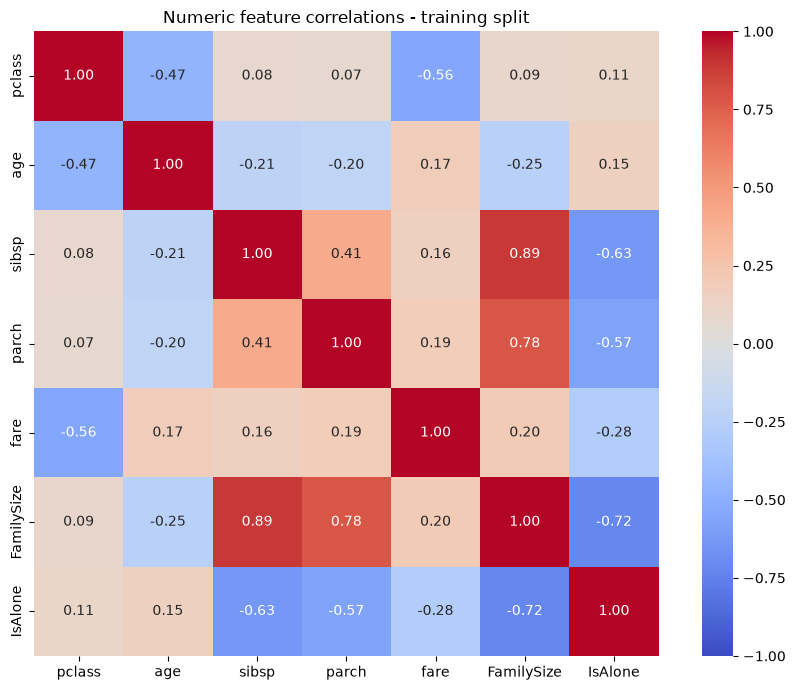

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 숫자형 피처만 선택합니다. 문자열 조합 피처는 아래 교차표로 확인합니다.
numeric_features = X_tr_features.select_dtypes(include="number")
feature_corr = numeric_features.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(feature_corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, square=True)
plt.title("Numeric feature correlations - training split")
plt.tight_layout()
plt.show()


FamilySize는 sibsp와 parch의 합이므로 높은 상관이 자연스럽습니다. IsAlone도 FamilySize에서 계산됩니다.
pclass와 fare의 음의 상관은 등급 숫자가 작을수록 높은 운임인 경향을 나타냅니다. 상관만으로 피처를 삭제하지 않습니다.


### 범주형 조합 피처 관계 히트맵
ClassIsChild와 기존 두 조합 피처의 **행별 구성 비율**을 봅니다. Pearson 상관계수가 아닙니다.
`1_1`은 1등급 어린이, `1_0`은 1등급 성인입니다. 각 행의 합은 100%이며 표본 수가 작은 행에 주의합니다.


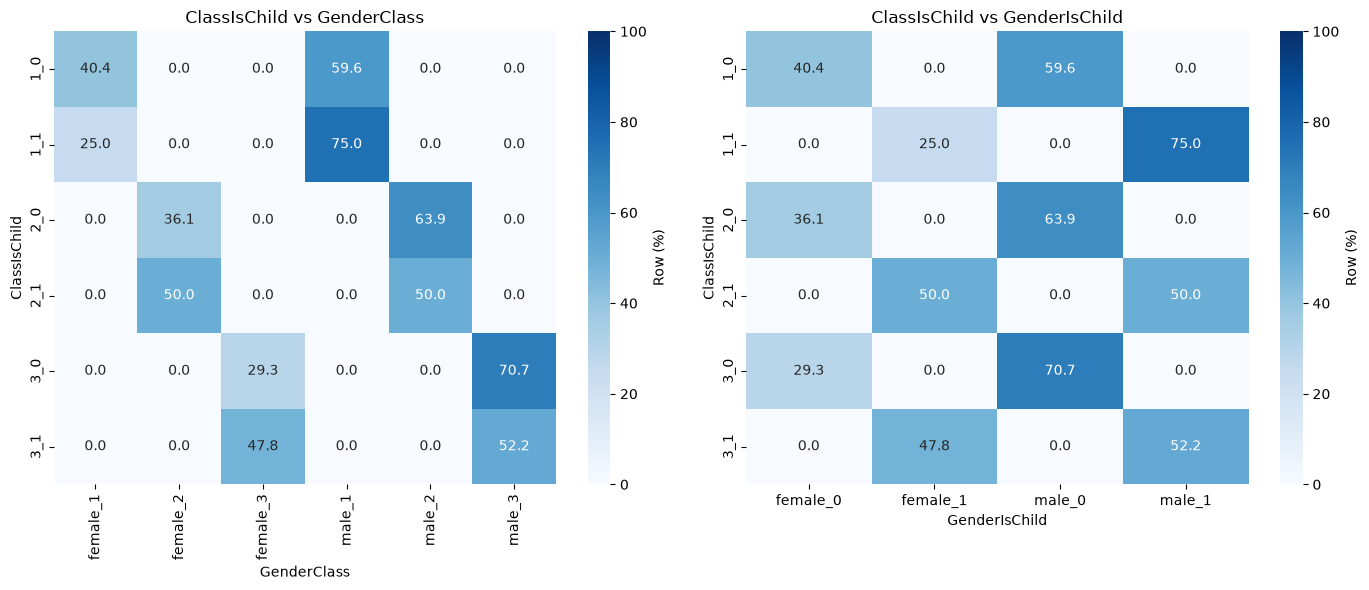

ClassIsChild별 표본 수
ClassIsChild
1_0    161
1_1      4
2_0    147
2_1     12
3_0    317
3_1     46
Name: count, dtype: int64


In [11]:
# 행별 비율: 각 ClassIsChild 집단 안에서 다른 조합이 차지하는 비율
class_gender_ratio = pd.crosstab(
    X_tr_features["ClassIsChild"], X_tr_features["GenderClass"],
    normalize="index"
) * 100
class_child_ratio = pd.crosstab(
    X_tr_features["ClassIsChild"], X_tr_features["GenderIsChild"],
    normalize="index"
) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(class_gender_ratio, annot=True, fmt=".1f", cmap="Blues",
            vmin=0, vmax=100, ax=axes[0], cbar_kws={"label": "Row (%)"})
axes[0].set_title("ClassIsChild vs GenderClass")
sns.heatmap(class_child_ratio, annot=True, fmt=".1f", cmap="Blues",
            vmin=0, vmax=100, ax=axes[1], cbar_kws={"label": "Row (%)"})
axes[1].set_title("ClassIsChild vs GenderIsChild")
plt.tight_layout()
plt.show()

print("ClassIsChild별 표본 수")
print(X_tr_features["ClassIsChild"].value_counts().sort_index())


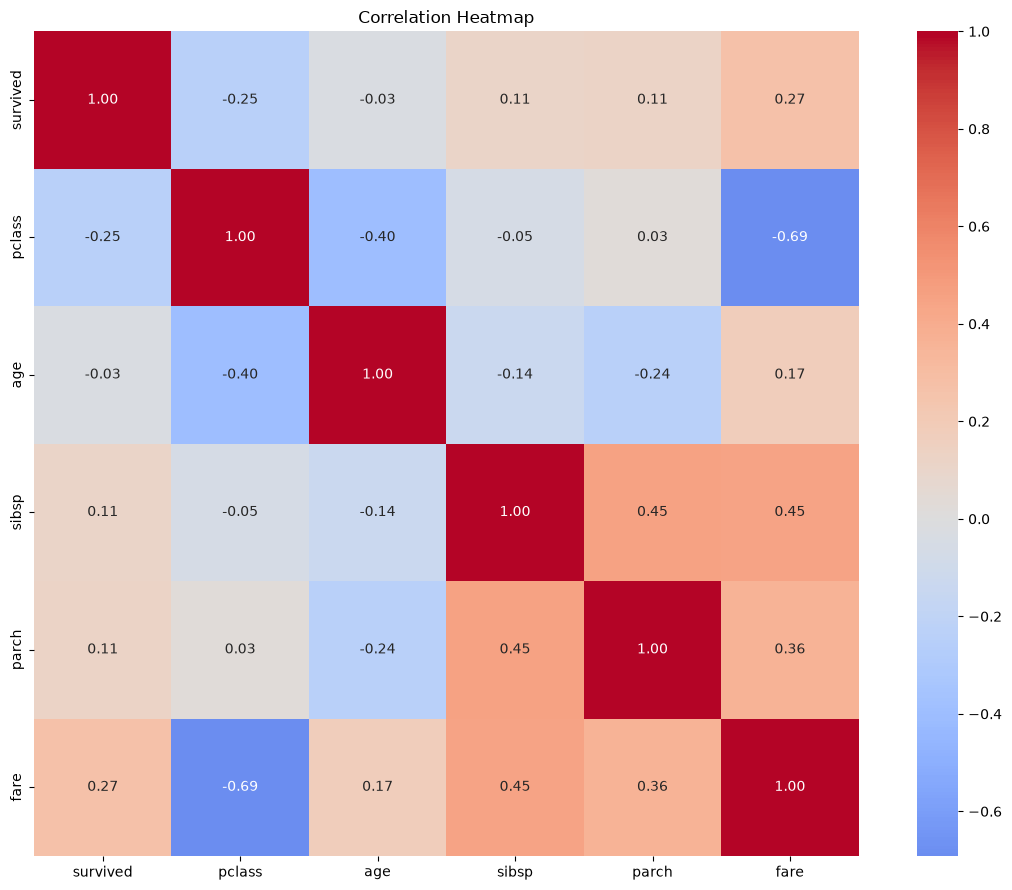

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 기존 피처 + 새로 생성한 피처 중
# 숫자로 의미 있게 비교할 수 있는 피처들
heatmap_features = [
    # 기존 Feature
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",

    # Baseline에서 생성
    "FamilySize",
    "IsAlone",

    # 새로 생성한 Feature
    "IsChild",
]

# 실제 데이터에 존재하는 컬럼만 선택
heatmap_features = [
    col for col in heatmap_features
    if col in train.columns
]

# 상관계수 계산
corr = train[heatmap_features].corr(method="spearman")

# Heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency


def cramers_v(x, y):
    # 교차표 생성
    confusion_matrix = pd.crosstab(x, y)

    # 카이제곱 검정
    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    # bias correction
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(kcorr - 1, rcorr - 1)

    if denominator <= 0:
        return 0

    return np.sqrt(phi2corr / denominator)

In [21]:
categorical_features = [
    "sex",
    "embarked",
    "GenderClass",
    "FamilyGroup",
    "CabinDeck",
    "GenderIsChild",
    "ClassIsChild",
    "GenderIsAlone",
    "EmbarkedClass",
    "TicketPrefix",
    "AgeBand"
]

# 실제 존재하는 컬럼만 사용
categorical_features = [
    col for col in categorical_features
    if col in train.columns
]

# Cramer's V Matrix 생성
cramer_matrix = pd.DataFrame(
    index=categorical_features,
    columns=categorical_features,
    dtype=float
)

for col1 in categorical_features:
    for col2 in categorical_features:
        cramer_matrix.loc[col1, col2] = cramers_v(
            train[col1],
            train[col2]
        )

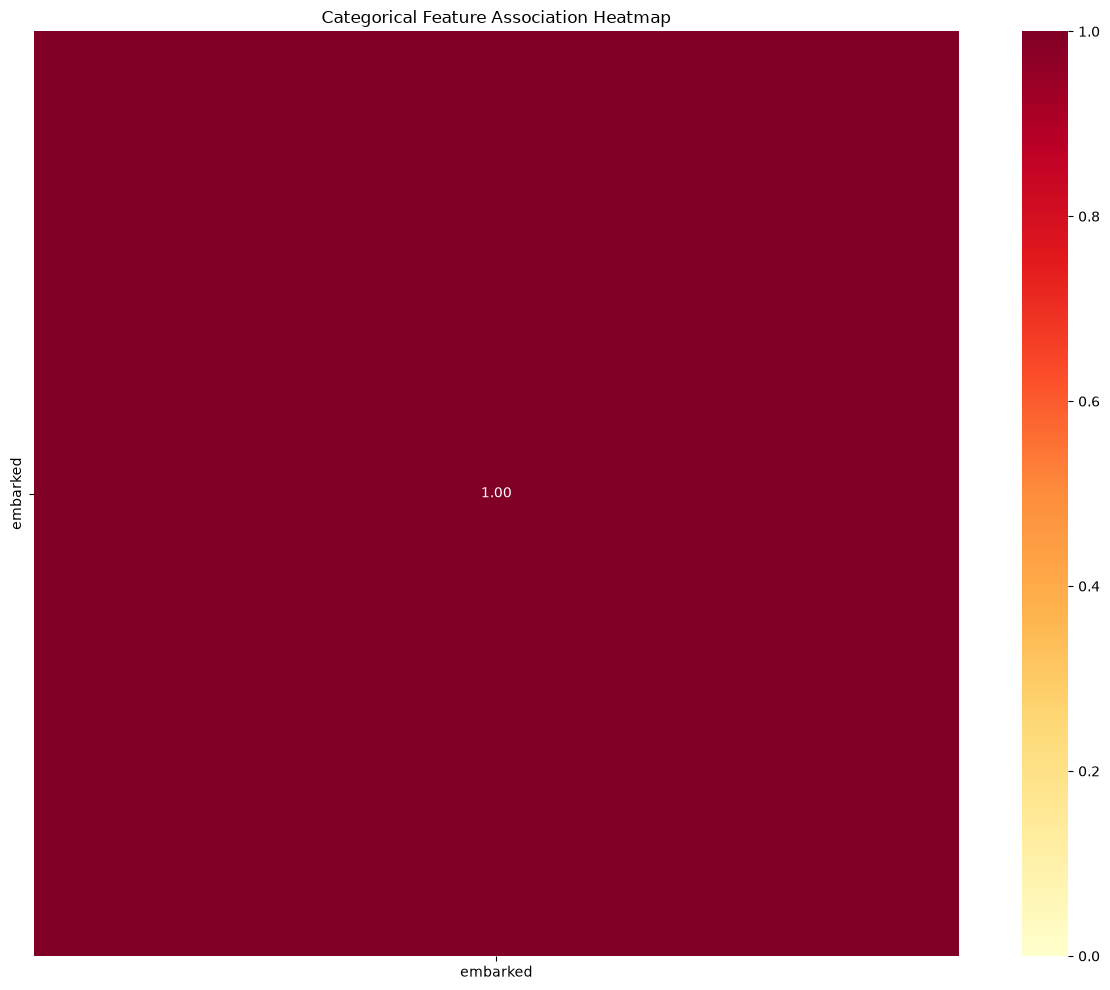

In [22]:
plt.figure(figsize=(13, 10))

sns.heatmap(
    cramer_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    square=True
)

plt.title("Categorical Feature Association Heatmap")
plt.tight_layout()
plt.show()

ClassIsChild는 GenderClass와 객실등급을 공유하고, GenderIsChild와 어린이 여부를 공유합니다.
따라서 특정 칸이 0%인 것은 조합 정의상 불가능한 경우도 포함합니다. 이 그림은 정보 중복을 읽는 데 사용하며, 피처의 유용성은 기존 validation/CV 결과와 함께 판단합니다.


## 6-4. Encoding
학습 부분에서만 OneHotEncoder를 fit하고 validation에는 transform만 합니다. 새로운 범주형도 같은 방식, 미관측 범주는 ignore입니다.

In [12]:
prep.fit_encoding(X_tr_features)
X_tr_model = prep.transform_encoding(X_tr_features)
X_valid_model = prep.transform_encoding(X_valid_features)
assert X_tr_model.columns.equals(X_valid_model.columns)
assert X_tr_model.index.equals(y_tr.index)
print(X_tr_model.shape, X_valid_model.shape)

(687, 28) (229, 28)


## 6-5. Scaling
Baseline과 동일하게 적용하지 않습니다.

In [13]:
assert np.isfinite(X_tr_model.to_numpy()).all()
assert np.isfinite(X_valid_model.to_numpy()).all()

# 7. 모델 학습
원본 baseline, 이전 Best, 후보를 동일한 모델로 학습합니다. 원본 baseline의 실제 파라미터 전체와 후보를 비교합니다. learning_rate 등의 자동 기본값도 같은 학습 크기에서 동일해야 합니다.

In [14]:
reference_prep = FeaturePreprocessor()
reference_X = reference_prep.fit_transform(X_tr_raw)
reference_valid = reference_prep.transform(X_valid_raw)
reference_model = fit_cat(reference_X, y_tr)
reference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)
assert abs(reference_scores['validation_auc'] - 0.900065) < 0.000001
previous_prep = FeaturePreprocessor(previous_features)
previous_X = previous_prep.fit_transform(X_tr_raw)
previous_valid = previous_prep.transform(X_valid_raw)
previous_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)
previous_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)
assert len(previous_features) != 1 or abs(previous_scores['validation_auc'] - 0.902911) < 0.000001
candidate_model = fit_cat(X_tr_model, y_tr)
assert candidate_model.get_all_params() == reference_model.get_all_params()
assert previous_model.get_all_params() == reference_model.get_all_params()
print('명시적 설정:', baseline_parameters())
print('실효 설정:', candidate_model.get_all_params())

명시적 설정: {'verbose': 0, 'random_state': 42, 'cat_features': [], 'allow_writing_files': False}
실효 설정: {'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'class_names': [0, 1], 'random_seed': 42, 'depth': 6, 'posterior_sampling': False, 'border_count': 254, 'classes_count': 0, 'auto_class_weights': 'None', 'sparse_features_conflict_fraction': 0, 'leaf_estimation_backtracking': 'AnyImprovement', 'best_mode

# 8. Evaluation
양성 클래스 확률로 AUC를 계산합니다. 이전 Best 대비 상승 후보만 5-fold를 수행합니다.

In [15]:
candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)
holdout_delta = candidate_scores['validation_auc'] - previous_scores['validation_auc']
original_delta = candidate_scores['validation_auc'] - reference_scores['validation_auc']
display(pd.DataFrame({'Original baseline':reference_scores, 'Previous best':previous_scores, 'Candidate':candidate_scores}))
print('이전 Best 대비:', holdout_delta, '최초 baseline 대비:', original_delta)
candidate_cv = None
cv_folds = None
if holdout_delta > 0:
    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)
    display(cv_folds.pivot(index='fold', columns='model', values='auc'))
    display(cv_table)
    previous_cv = cv_table.loc['Previous best'].to_dict()
    candidate_cv = cv_table.loc['Candidate'].to_dict()
accepted = (holdout_delta > 0 and candidate_cv is not None
            and candidate_cv['mean'] >= previous_cv['mean']
            and candidate_cv['std'] <= previous_cv['std'] + 0.005
            and candidate_scores['gap'] <= previous_scores['gap'] + 0.01)
best_features = candidate_features if accepted else previous_features
best_scores = candidate_scores if accepted else previous_scores
best_cv = candidate_cv if accepted else previous_cv
print('채택:', accepted, '다음 버전의 Best:', best_features)

,Original baseline,Previous best,Candidate
train_auc,0.963079,0.965065,0.964795
validation_auc,0.900065,0.904293,0.906489
gap,0.063014,0.060771,0.058306


이전 Best 대비: 0.0021954789396648744 최초 baseline 대비: 0.006423808749390081
Fold 1 완료
Fold 2 완료
Fold 3 완료
Fold 4 완료
Fold 5 완료


model,Candidate,Original baseline,Previous best
fold,,,
1,0.897932,0.891917,0.896429
2,0.926329,0.919082,0.924422
3,0.878528,0.878782,0.880943
4,0.911772,0.906433,0.910882
5,0.916603,0.912662,0.916857


,mean,std
model,,
Candidate,0.906233,0.018564
Original baseline,0.901775,0.016322
Previous best,0.905907,0.017324


채택: True 다음 버전의 Best: ['GenderClass', 'GenderIsChild', 'ClassIsChild']


# 9. 전체 Train 재학습
요청한 버전별 CSV는 채택 여부와 무관하게 이번에 실험한 후보 피처로 생성합니다. 다음 실험은 채택된 Best만 이어받습니다. 전체 train 학습도 같은 크기의 원본 baseline과 실효 파라미터를 대조합니다.

In [16]:
full_reference_prep = FeaturePreprocessor()
full_reference_X = full_reference_prep.fit_transform(X)
full_reference_model = fit_cat(full_reference_X, y)
final_prep = FeaturePreprocessor(candidate_features)
X_full_model = final_prep.fit_transform(X)
submission_model = fit_cat(X_full_model, y)
assert submission_model.get_all_params() == full_reference_model.get_all_params()
print('이 버전 CSV의 피처:', X_full_model.columns.tolist())
print('최종 학습 실효 파라미터:', submission_model.get_all_params())

이 버전 CSV의 피처: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1']
최종 학습 실효 파라미터: {'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'ran

# 10. Test 예측

In [17]:
X_test_model = final_prep.transform(X_test_raw)
assert X_test_model.columns.equals(X_full_model.columns)
positive_index = list(submission_model.classes_).index(1)
predictions = submission_model.predict_proba(X_test_model)[:, positive_index]
assert np.isfinite(predictions).all()
assert ((predictions>=0)&(predictions<=1)).all()

# 11. Submission 생성
템플릿 예측 열만 교체하고 원래 ID/순서를 유지합니다. 기존 버전 덮어쓰기를 방지합니다.

In [18]:
output_path = Path('submission/titanic_result_11.csv')
assert not output_path.exists(), '기존 결과를 덮어쓰지 않습니다.'
assert submission.columns.tolist()==[id_col,target_col]
assert len(submission)==len(test)
assert submission[id_col].is_unique and submission[id_col].notna().all()
assert set(submission[id_col])==set(test[id_col])
result = submission.copy(deep=True)
by_id = pd.Series(predictions,index=test[id_col].to_numpy())
result[target_col] = result[id_col].map(by_id)
assert result[target_col].notna().all()
result.to_csv(output_path,index=False)
saved = pd.read_csv(output_path)
assert saved.shape==submission.shape==(len(test),2)
assert saved.columns.equals(submission.columns)
pd.testing.assert_frame_equal(saved.drop(columns=target_col),submission.drop(columns=target_col))
assert pd.api.types.is_float_dtype(saved[target_col])
assert saved[target_col].notna().all() and saved[target_col].between(0,1).all()
np.testing.assert_allclose(saved[target_col],by_id.loc[submission[id_col]],atol=1e-15,rtol=1e-12)
print('검증 통과:', output_path, saved.shape)

AssertionError: 기존 결과를 덮어쓰지 않습니다.

## 실제 EDA 결과와 중복성 해석
1등급 어린이는 4명/75.0%, 2등급 어린이 12명/91.7%, 3등급 어린이 46명/39.1%다. 1·2등급 어린이는 소표본이다. pclass/age를 재표현하고 GenderIsChild와 어린이 구분을 공유하지만 누적 추가 시 holdout/CV가 개선됐다. 개선 폭이 작아 추가 독립 검증이 필요하다.

# 12. 해당 버전 실험 결과

가설: 어린이의 생존 패턴이 등급마다 다를 수 있어 등급과 어린이 여부를 조합한다.

| 항목 | 이전 Best | 이번 실험 |
|---|---:|---:|
| train_auc | 0.965065 | 0.964795 |
| validation_auc | 0.904293 | 0.906489 |
| gap | 0.060771 | 0.058306 |
| CV mean | 0.905907 | 0.906233 |
| CV std | 0.017324 | 0.018564 |

**채택**: holdout/CV 평균 개선 및 Gap 기준 통과. 이전 Best 대비 +0.002195, 최초 baseline 대비 +0.006424.

다음 버전의 추가 피처: ['GenderClass', 'GenderIsChild', 'ClassIsChild'].
이번 CSV 입력: ['GenderClass', 'GenderIsChild', 'ClassIsChild'].

기존 피처와의 관계: pclass와 age로 계산되어 원천 정보는 같다. 어린이 조합의 작은 표본과 다른 어린이 interaction과의 중복에 주의한다.
개별 집단 비율은 EDA 표에 있으며 소표본/인과관계 해석에 주의합니다. CV 미실행은 0점이 아니라 holdout에서 우선 제외했음을 의미합니다.


NameError: name 'train' is not defined